In [1]:
from google.colab import files
uploaded = files.upload()

Saving full_format_recipes.json to full_format_recipes.json


In [3]:
#loading the dataset "full_format_recipes.json"

import json

with open('full_format_recipes.json') as f:
    data = json.load(f)

print("No. of recipes: ", len(data))
print("Fields in recipe: ", data[0].keys())

No. of recipes:  20130
Fields in recipe:  dict_keys(['directions', 'fat', 'date', 'categories', 'calories', 'desc', 'protein', 'rating', 'title', 'ingredients', 'sodium'])


In [5]:
import pandas as pd

# Convert the list of recipes to a DataFrame
df = pd.DataFrame(data)

# Check for null values in each column
null_counts = df.isnull().sum()
print("Null values per field:")
display(null_counts)

Null values per field:


,0
directions,19
fat,4222
date,19
categories,19
calories,4154
desc,6635
protein,4201
rating,30
title,19
ingredients,19


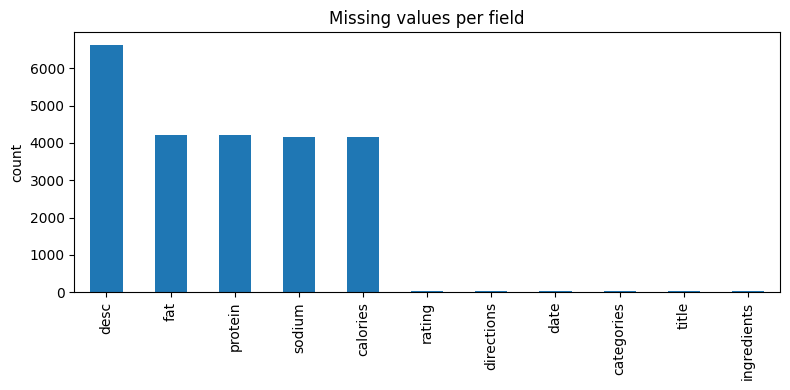

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(data)

# Missing values per field -- justifies dropping recipes without nutrition
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
missing.plot(kind="bar")
plt.title("Missing values per field")
plt.ylabel("count")
plt.tight_layout(); plt.show()

Bon Appétit          9355
Peanut Free          8390
Soy Free             8088
Tree Nut Free        7044
Vegetarian           6846
Gourmet              6648
Kosher               6175
Pescatarian          6042
Quick & Easy         5372
Wheat/Gluten-Free    4906
Bake                 4413
Summer               4151
Dessert              3573
Dairy Free           3206
Side                 3151
No Sugar Added       3132
Winter               3099
Fall                 3015
Dinner               2705
Sugar Conscious      2466
dtype: int64


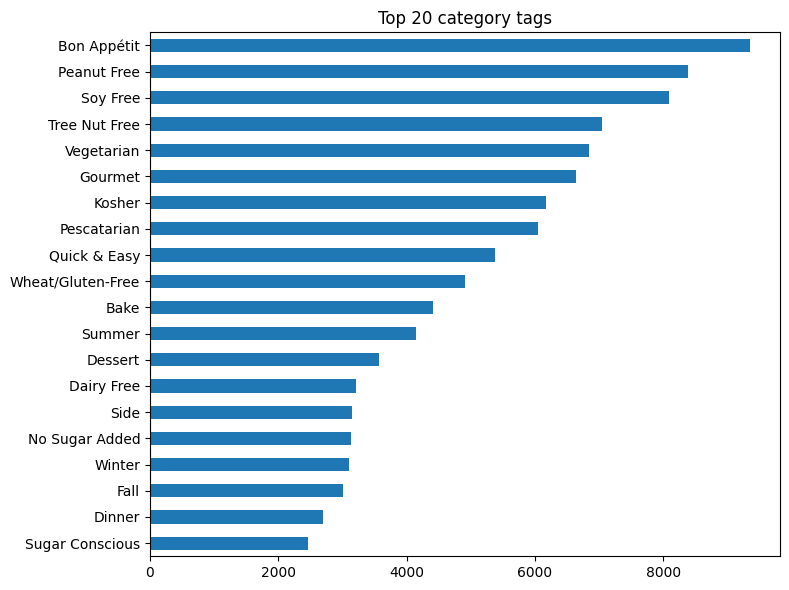

In [ ]:
#Top 20 tags -- visually proves diet/allergen tags common, cuisine tags absent
from collections import Counter
tag_counts = Counter(t for r in data for t in (r.get("categories") or []))
top = pd.Series(dict(tag_counts.most_common(20)))
print(top)
plt.figure(figsize=(8, 6))
top.sort_values().plot(kind="barh")
plt.title("Top 20 category tags")
plt.tight_layout(); plt.show()

In [44]:
# since food is a sensitive topic, hence we cannot fill the missing values (numeric) with average, bfill or ffill etc
# Keeping only recepies we can use

usable = [
    r for r in data
    if r.get("title") and r.get("ingredients") and r.get("directions") and r.get("calories") is not None and r.get("protein") is not None
]

print("No. of recipes: ", len(usable))


No. of recipes:  15922


In [45]:
# checking the receipe structure

sample = usable[0]
print("\nTITLE:", sample["title"])
print("CALORIES:", sample["calories"], "| PROTEIN:", sample["protein"])
print("\nINGREDIENTS:")
for line in sample["ingredients"]:
    print("  -", line)
print("\nCATEGORIES (tags):", sample["categories"])


TITLE: Lentil, Apple, and Turkey Wrap 
CALORIES: 426.0 | PROTEIN: 30.0

INGREDIENTS:
  - 4 cups low-sodium vegetable or chicken stock
  - 1 cup dried brown lentils
  - 1/2 cup dried French green lentils
  - 2 stalks celery, chopped
  - 1 large carrot, peeled and chopped
  - 1 sprig fresh thyme
  - 1 teaspoon kosher salt
  - 1 medium tomato, cored, seeded, and diced
  - 1 small Fuji apple, cored and diced
  - 1 tablespoon freshly squeezed lemon juice
  - 2 teaspoons extra-virgin olive oil
  - Freshly ground black pepper to taste
  - 3 sheets whole-wheat lavash, cut in half crosswise, or 6 (12-inch) flour tortillas
  - 3/4 pound turkey breast, thinly sliced
  - 1/2 head Bibb lettuce

CATEGORIES (tags): ['Sandwich', 'Bean', 'Fruit', 'Tomato', 'turkey', 'Vegetable', 'Kid-Friendly', 'Apple', 'Lentil', 'Lettuce', 'Cookie']


In [46]:
import re

# Common measurement/prep words that carry no flavour signal.
STOPWORDS = set("""
cup cups tablespoon tablespoons tbsp teaspoon teaspoons tsp ounce ounces oz pound pounds lb lbs gram grams kg ml liter liters pinch dash clove cloves can cans package packages slice slices
piece pieces large small medium chopped diced sliced minced fresh freshly ground peeled cored seeded canned jarred bottled frozen dried packed drained rinsed cooked uncooked raw boneless skinless
""".split())

def clean_ingredients(ingredient_lines):
    """Turn messy ingredient lines into a bag of meaningful ingredient words."""
    words = []
    for line in ingredient_lines:
        line = line.lower()
        line = re.sub(r"[^a-z ]", " ", line)   # drop numbers & punctuation
        for word in line.split():
            if len(word) > 2 and word not in STOPWORDS:
                words.append(word)
    return " ".join(words)

# Testing it on our sample so we SEE what it does
print("BEFORE:", usable[0]["ingredients"][:3])
print("\nAFTER: ", clean_ingredients(usable[0]["ingredients"]))

BEFORE: ['4 cups low-sodium vegetable or chicken stock', '1 cup dried brown lentils', '1/2 cup dried French green lentils']

AFTER:  low sodium vegetable chicken stock brown lentils french green lentils stalks celery carrot and sprig thyme kosher salt tomato and fuji apple and squeezed lemon juice extra virgin olive oil black pepper taste sheets whole wheat lavash cut half crosswise inch flour tortillas turkey breast thinly head bibb lettuce


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build one "document" per recipe: cleaned ingredients + its tags.
# Tags get joined into single tokens (spaces -> underscores) so
# "Kid-Friendly" stays one term, not two.
documents = []
for r in usable:
    ingredient_text = clean_ingredients(r["ingredients"])
    tag_text = " ".join(t.lower().replace(" ", "_") for t in r["categories"])
    documents.append(ingredient_text + " " + tag_text)

titles = [r["title"].strip() for r in usable]

# Fit TF-IDF over every recipe document.
vectorizer = TfidfVectorizer(min_df=5, max_df=0.5, stop_words="english")
recipe_vectors = vectorizer.fit_transform(documents)

print("Recipe vectors:", recipe_vectors.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Recipe vectors: (15922, 2575)
Vocabulary size: 2575


In [48]:
from sklearn.metrics.pairwise import cosine_similarity

def find_similar(recipe_index, how_many=100):
    """Given a recipe, return the most similar other recipes."""
    # Similarity of this recipe's vector against every recipe.
    scores = cosine_similarity(recipe_vectors[recipe_index], recipe_vectors).ravel()
    # Sort high-to-low; skip position 0 (the recipe itself).
    best = scores.argsort()[::-1][1 : how_many + 1]
    return [(titles[i], round(float(scores[i]), 3)) for i in best]

# Try it: pick a recipe, see what it thinks is similar.
probe = 0
print("PROBE RECIPE:", titles[probe])
print("\nMost similar:")
for title, score in find_similar(probe):
    print(f"  {score}  {title}")

PROBE RECIPE: Lentil, Apple, and Turkey Wrap

Most similar:
  0.36  Golden Lentil Dip
  0.357  Braised Lentils
  0.355  Garlicky Lentil Soup
  0.348  Pasta with Lentil Bolognese
  0.341  French Lentil Soup
  0.312  Herb-Stuffed Chicken with Caramelized Onion, Lentil, and Feta Salad
  0.305  Savory Lentil and Squash Soup
  0.296  Roasted Poultry Stock
  0.296  Roasted Poultry Stock
  0.286  Pot Luck Soup
  0.281  Fried Eggs Over Warm Lentil Salad with Lardons
  0.279  Wild Rice with French Green Lentils
  0.278  Lime Soup with Tortilla Strips and Chicken
  0.276  Turkey Stock
  0.276  Turkey Stock
  0.276  Roast Turkey with Port Gravy
  0.269  Duck-Fat Turkey Breasts with Green Onion Puree
  0.268  Walnut Chicken Salad with Green Apple Vinaigrette
  0.267  French Lentil Soup with Sausage
  0.264  3-Ingredient Sausage Dinner With Lentils and Fennel
  0.263  Kielbasa and Lentil Salad with Warm Mustard-Fennel Dressing
  0.261  Spinach and Lentil Soup
  0.259  Tomatoes Stuffed with Bulgur a

In [ ]:
import numpy as np

def build_taste_vector(rated):
    """
    Build a single 'taste' vector from a user's ratings.
    `rated` is a list of (recipe_index, stars) pairs, stars 1-5.
    """
    weighted_sum = None
    for recipe_index, stars in rated:
        weight = stars - 3     
        vec = recipe_vectors[recipe_index] * weight
        weighted_sum = vec if weighted_sum is None else weighted_sum + vec
    return weighted_sum


def recommend_for_user(rated, how_many=5):
    """Recommend recipes based on a user's taste, skipping ones they've rated."""
    taste = build_taste_vector(rated)
    scores = cosine_similarity(taste, recipe_vectors).ravel()
    already_rated = {i for i, _ in rated}
    order = scores.argsort()[::-1]
    results = []
    for i in order:
        if i in already_rated:
            continue
        results.append((titles[i], round(float(scores[i]), 3)))
        if len(results) == how_many:
            break
    return results


# Simulate a user who loves lentil/legume dishes.
# (probe 0 was the lentil wrap — let's say they rated it and a couple of neighbours highly)
my_ratings = [
    (0, 5),    # Lentil, Apple, and Turkey Wrap - loved it
    (500, 5),
    (12000,1)
]
print("Recommendations based on your taste:")
for title, score in recommend_for_user(my_ratings):
    print(f"  {score}  {title}")

Recommendations based on your taste:
  0.296  Chicken and Corn Chowder with Thyme
  0.293  Savory Lentil and Squash Soup
  0.289  Butternut Squash Soup with Cider Cream
  0.27  Butternut Squash Soup with Pancetta and Tomatoes
  0.258  Southwestern Turkey with Garlic-Ancho Chili Paste and Gravy


In [50]:
print("Liked:", titles[0], "|", titles[500])
print("Disliked:", titles[12000])

Liked: Lentil, Apple, and Turkey Wrap | Butternut-Corn Chowder with Goat Cheese Croutons
Disliked: Yam and Black Bean Burritos with Amaranth


In [51]:
def recommend_filtered(rated, diet=None, allergies=None,
                       min_protein=None, max_calories=None, how_many=5):
    """
    Recommend recipes that (1) pass the user's hard constraints,
    then (2) are ranked by taste.
    - diet: 'Vegetarian' or 'Pescatarian' (None = no restriction)
    - allergies: list of ingredient keywords to exclude, e.g. ['peanut']
    """
    allergies = allergies or []
    taste = build_taste_vector(rated)
    scores = cosine_similarity(taste, recipe_vectors).ravel()
    already_rated = {i for i, _ in rated}

    order = scores.argsort()[::-1]
    results = []
    for i in order:
        if i in already_rated:
            continue
        recipe = usable[i]

        # --- HARD FILTERS (all must pass) ---
        # diet
        if diet and diet not in recipe["categories"]:
            continue
        # allergies: skip if any allergen keyword appears in the ingredients
        ingredient_blob = " ".join(recipe["ingredients"]).lower()
        if any(a.lower() in ingredient_blob for a in allergies):
            continue
        # nutrition
        if min_protein is not None and recipe["protein"] < min_protein:
            continue
        if max_calories is not None and recipe["calories"] > max_calories:
            continue

        results.append((titles[i],
                        round(float(scores[i]), 3),
                        f"{recipe['protein']:.0f}g protein, {recipe['calories']:.0f} cal"))
        if len(results) == how_many:
            break
    return results


# Same lentil/squash taste, but now: Vegetarian only, no peanuts, protein >= 15g
recs = recommend_filtered(
    my_ratings,
    diet="Vegetarian",
    allergies=["peanut"],
    min_protein=15,
)
print("Filtered recommendations (Vegetarian, no peanut, protein>=15g):")
for title, score, nutrition in recs:
    print(f"  {score}  {title}  ({nutrition})")

Filtered recommendations (Vegetarian, no peanut, protein>=15g):
  0.226  Garlicky Lentil Soup  (17g protein, 311 cal)
  0.201  Warm Goat Cheese Salad with Pears and Walnuts  (23g protein, 796 cal)
  0.189  Roasted Eggplant Soup with Goat Cheese Dumplings  (15g protein, 456 cal)
  0.186  French Lentil Soup  (16g protein, 340 cal)
  0.176  Pizza with Leeks, Tomato and Goat Cheese  (32g protein, 1052 cal)


In [52]:
feature_names = np.array(vectorizer.get_feature_names_out())

def explain(recipe_index, rated, top_n=4):
    """
    Explain why a recipe was recommended: the ingredient terms it most
    shares with the user's taste.
    """
    taste = build_taste_vector(rated)
    taste_arr = np.asarray(taste.todense()).ravel()
    recipe_arr = np.asarray(recipe_vectors[recipe_index].todense()).ravel()

    # Where both the recipe and the taste have weight, they overlap.
    overlap = recipe_arr * taste_arr
    top_terms = feature_names[overlap.argsort()[::-1][:top_n]]
    # keep only real overlaps (weight > 0)
    top_terms = [t for t in top_terms if overlap[feature_names.tolist().index(t)] > 0]
    return top_terms


# Explain the top filtered recommendation
recs = recommend_filtered(my_ratings, diet="Vegetarian",
                          allergies=["peanut"], min_protein=15)
top_title = recs[0][0]
top_index = titles.index(top_title)
shared = explain(top_index, my_ratings)
print(f"Recommended: {top_title}")
print(f"Because it shares: {', '.join(shared)} with dishes you rated highly")

Recommended: Garlicky Lentil Soup
Because it shares: lentils, lentil, taste, french with dishes you rated highly
